# Lazy `Dataset` — complete cookbook

This notebook exercises **every** lazy surface that `pyramids.dataset.Dataset` exposes, against local test data shipped with pyramids. Nothing here hits the network — you can run it end-to-end after a `pip install 'pyramids-gis[lazy]'`.

## What you'll see

1. `Dataset.read_array(chunks=…)` — eager vs lazy returns.
2. Picking a chunk size and inspecting the task graph.
3. `dask.array` reductions and arithmetic over the lazy array.
4. `Dataset.to_zarr` / `Dataset.from_zarr` — the only truly-parallel raster output path.
5. `focal_mean`, `focal_std`, `focal_apply`, `slope`, `aspect`, `hillshade` — every neighbourhood op accepts the same `chunks=` switch.
6. `zonal_stats` over a polygon FeatureCollection.
7. Dispatch helpers: `is_lazy`, `as_numpy`.

## Requirements

```bash
pip install 'pyramids-gis[lazy]'
```

## Setup — imports and the data path

`%matplotlib inline` renders every plot inside the notebook. We import `numpy` (used for a user kernel later)
and resolve `DATA` to the repo's `examples/data/` folder **relative to this notebook**. Every raster read below
is local — nothing touches the network.

In [1]:
%matplotlib inline

from pathlib import Path

import numpy as np

DATA = Path('..') / '..' / '..' / 'examples' / 'data'
DATA = DATA.resolve()
DATA.is_dir()

True

## 1. `Dataset.read_array(chunks=…)` — eager vs lazy

The `chunks=` argument is the single switch that flips a read from eager to lazy. It is local to the call —
no global mode, no subclass:

| `chunks=` value | Return type | Reads on call? |
|---|---|---|
| `None` (default) | `numpy.ndarray` | yes — eager |
| tuple / int / `"auto"` | `dask.array.Array` | no — lazy, builds a task graph |

Below we first load the raster, look at it, then read its band both ways.

In [2]:
from pyramids.dataset import Dataset

ds = Dataset.read_file(DATA / 'acc4000.tif')
ds.shape, ds.cell_size, ds.epsg

2026-07-01 17:23:46 | INFO | pyramids.base.config | Logging is configured.


((1, 13, 14), 4000.0, 32618)

### Visualise the source raster

`Dataset` is always eager, so it plots directly. This is the `acc4000` flow-accumulation grid every lazy read below draws from.

C:\python-environments\pixi\envs\pyramids-gis-17387402636982928789\envs\dev\Lib\site-packages\matplotlib\colors.py:816: RuntimeWarning: overflow encountered in multiply
  xa *= self.N


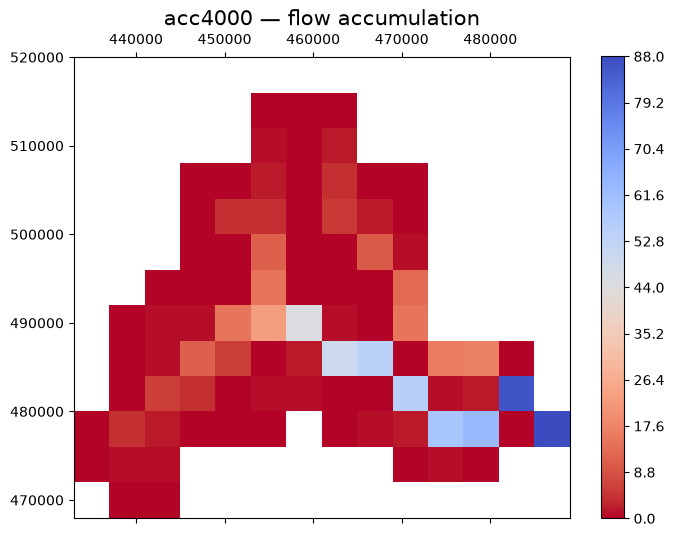

In [3]:
ds.plot(band=0, title="acc4000 — flow accumulation")

The bright cells are the high flow-accumulation pixels — the river network draining the basin. This eager
`Dataset` is the source every lazy read below draws from. The next two cells read its band **two ways** so you
can see the eager vs lazy difference back to back.

### Eager read — the default `read_array()`

With no `chunks=`, `read_array()` returns a plain `numpy.ndarray` and never imports dask.

In [4]:
# Eager — numpy array.
eager = ds.read_array()
type(eager).__name__, eager.shape, eager.dtype

('ndarray', (13, 14), dtype('float32'))

### Lazy read — opt in with `chunks=`

Passing any `chunks=` value returns a `dask.array.Array` instead. Here `.chunks` reports `((13,), (14,))`: the
grid is smaller than the 32×32 request, so it collapses to a single chunk. Nothing has been read from disk yet.

In [5]:
# Lazy — dask array. Nothing is read yet.
lazy = ds.read_array(chunks=(32, 32))
type(lazy).__name__, lazy.shape, lazy.chunks

('Array', (13, 14), ((13,), (14,)))

### Dispatch helpers — `is_lazy`, `as_numpy`

Library code that accepts either backend should use the structural helpers in `pyramids.base.protocols` instead of comparing against `np.ndarray` / `dask.array.Array` directly.

In [6]:
from pyramids.base.protocols import as_numpy, is_lazy

is_lazy(eager), is_lazy(lazy)

(False, True)

`is_lazy` is `True` only for the dask array — a structural check that doesn't require the caller to import dask.
`as_numpy` then normalises either backend to numpy: a no-op on the eager array, a `.compute()` on the lazy one.

In [7]:
# as_numpy is a no-op on numpy, and forces a compute on dask.
materialised = as_numpy(lazy)
type(materialised).__name__, materialised.shape

('ndarray', (13, 14))

## 2. Reductions and arithmetic over the lazy array

Every `dask.array` op is available — pyramids does not add a wrapper. The graph is built without touching the file; `.compute()` triggers the read + reduction.

In [8]:
lazy = ds.read_array(chunks=(32, 32))

# Build an arithmetic graph — no I/O yet.
anomaly = lazy - lazy.mean()
len(anomaly.__dask_graph__())

4

The graph now holds 4 tasks and still no I/O has happened. `.compute()` triggers the read plus the reduction:

In [9]:
# Materialise.
result = anomaly.compute()
result.shape, float(result.min()), float(result.max())

C:\python-environments\pixi\envs\pyramids-gis-17387402636982928789\envs\dev\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


((13, 14), inf, inf)

Note the `inf` result and the overflow warning: `acc4000` is `float32`, and summing it to form the mean overflows
the dtype. This is a property of the **data and dtype**, not of laziness — the eager path overflows identically.
Lazy evaluation changes *when* the read happens, never the arithmetic.

## 3. Parallel writes — `Dataset.to_zarr` / `from_zarr`

Zarr is the only raster output where pyramids can do truly parallel writes: each dask chunk lands in an
independent chunk file. The store carries rioxarray-compatible geobox attributes, so downstream consumers can
reopen it without pyramids.

| Parameter | Meaning |
|---|---|
| `chunks=(1, 32, 32)` | `(band, row, col)` chunk shape — one Zarr chunk file per block |
| `mode='w'` | overwrite the store if it already exists |

In [10]:
import tempfile

workdir = Path(tempfile.mkdtemp(prefix='pyramids-lazy-'))
store = workdir / 'acc4000.zarr'
ds.to_zarr(store, chunks=(1, 32, 32), mode='w')
sorted(p.name for p in store.iterdir())[:5]

['data', 'spatial_ref', 'x', 'y', 'zarr.json']

The store is a directory of independent chunk files (`data`, the coordinate arrays `x`/`y`, `spatial_ref`, and
the `zarr.json` metadata). Reopening it stays lazy when `chunks=` is passed:

In [11]:
# Round-trip back into a Dataset — still lazy if chunks is given.
reloaded = Dataset.from_zarr(store, chunks=(1, 32, 32))
reloaded.epsg, reloaded.shape, reloaded.cell_size

(32618, (1, 13, 14), 4000.0)

The geobox survives the round-trip — same EPSG, shape, and cell size. Because the attributes are plain JSON, a
consumer can read the georeferencing without pyramids at all:

In [12]:
# The Zarr attributes are readable without pyramids — just json. Zarr v3
# stores them under the "attributes" key of each node's zarr.json.
import json

meta = json.loads((store / 'data' / 'zarr.json').read_text())['attributes']
meta['epsg'], meta['dtype'], meta['GeoTransform']

(32618, 'float32', '432968.1206170588 4000.0 0.0 520007.787999178 0.0 -4000.0')

## 4. Neighbourhood ops — `focal_mean` / `_std` / `_apply`

Every focal op takes the same `chunks=` switch and resolves to `dask.array.map_overlap(kernel, depth=radius, boundary='reflect')` when it's set. The eager kernel is unchanged (SciPy `ndimage` filters); only the halo bookkeeping changes.

In [13]:
# Eager focal mean.
mean_eager = ds.focal_mean(radius=1)
type(mean_eager).__name__, mean_eager.shape

('ndarray', (13, 14))

### Same op, lazy backend

The identical `focal_mean(radius=1)` call with `chunks=` set returns a dask array. Internally it becomes
`map_overlap(kernel, depth=1, boundary='reflect')`, so each chunk gets a 1-pixel halo — the kernel is unchanged.

In [14]:
# Lazy focal mean — same radius, chunks= provided.
mean_lazy = ds.focal_mean(radius=1, chunks=(32, 32))
type(mean_lazy).__name__, mean_lazy.chunks

('Array', ((13,), (14,)))

`focal_apply` runs an arbitrary NumPy callable over each window — here a per-window `np.max`. It reuses the same
halo machinery, so a user-supplied kernel parallelises for free:

In [15]:
# User kernel via focal_apply — per-window max over a 3x3 window.
big_max = ds.focal_apply(np.max, radius=1, chunks=(32, 32))
materialised_max = big_max.compute()
float(materialised_max.max())

88.0

`focal_std` uses a two-pass variance formulation. On a constant patch the variance is exactly zero, but an
unstable one-pass formula could return a tiny negative float; the check below confirms the result is `>= 0`:

In [16]:
# focal_std uses a two-pass formulation. A constant
# raster has zero variance, which the unstable formulation
# can return as a tiny negative float — we should see 0.
zero_std = ds.focal_std(radius=1, chunks=(32, 32))
float(zero_std.min().compute()) >= 0.0

True

## 5. DEM derivatives — `slope`, `aspect`, `hillshade`

The three classic DEM ops wrap centered-difference gradients. On lazy inputs the gradient is computed per chunk via the same `map_overlap` path.

In [17]:
dem = Dataset.read_file(DATA / 'dem' / 'DEM5km_Rhine_burned_acc.tif')
dem.shape, dem.cell_size

((1, 125, 93), 5000.0)

### The DEM behind the derivatives

The Rhine DEM is the eager input the lazy `slope` / `aspect` / `hillshade` ops below derive from. Plotting it shows the terrain those neighbourhood kernels run over.

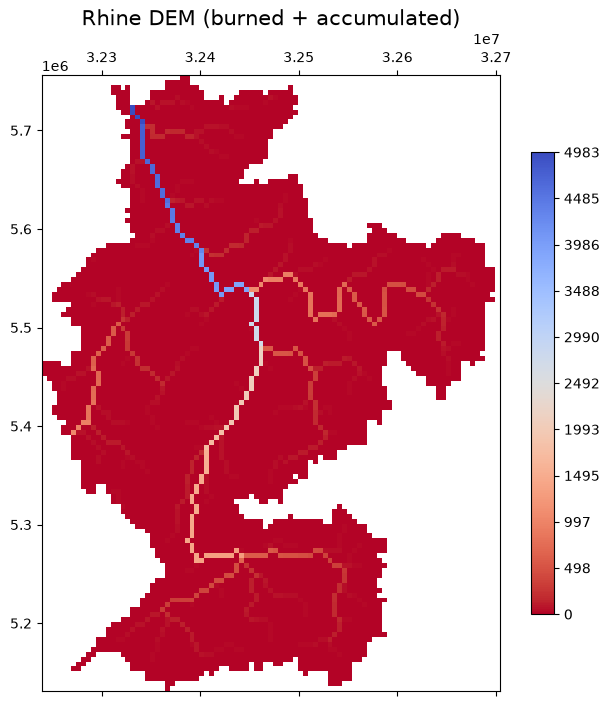

In [18]:
dem.plot(band=0, title="Rhine DEM (burned + accumulated)")

This is the terrain the DEM derivatives run over. `slope`, `aspect`, and `hillshade` are all centered-difference
gradient ops; with `chunks=` set each is computed per chunk through the same `map_overlap` halo path. We build
all three lazily in one cell:

In [19]:
slope_lazy = dem.slope(chunks=(64, 64), units='degrees')
aspect_lazy = dem.aspect(chunks=(64, 64))
shade_lazy = dem.hillshade(azimuth=315.0, altitude=45.0, chunks=(64, 64))
slope_lazy.shape, aspect_lazy.shape, shade_lazy.shape

((125, 93), (125, 93), (125, 93))

All three are still lazy — only their shapes are known so far. We materialise just the hillshade, the most
visually meaningful of the derivatives:

In [20]:
# Materialise hillshade once — it's the most visually
# meaningful of the three derivatives.
shade = shade_lazy.compute()
float(shade.min()), float(shade.max())

(0.0, 245.09083049498994)

## 6. Zonal statistics — `Dataset.zonal_stats`

Single-pass: every polygon is rasterised into one integer label grid; `np.bincount` then gives mean / sum / count. The FeatureCollection must share the Dataset's CRS (pyramids raises instead of silently mis-aligning).

In [21]:
from pyramids.feature import FeatureCollection

polys = FeatureCollection.read_file(
    DATA / 'coello_polygons.geojson',
)
# Match the raster CRS.
polys = FeatureCollection(polys.to_crs(ds.epsg))
len(polys), polys.epsg

(4, 32618)

With the polygons reprojected to the raster CRS, `zonal_stats` rasterises all four into one integer label grid
and uses `np.bincount` for a single-pass mean / sum / count:

In [22]:
stats = ds.zonal_stats(polys, stats=('mean', 'sum', 'count'))
stats.head()

C:\python-environments\pixi\envs\pyramids-gis-17387402636982928789\envs\dev\Lib\site-packages\osgeo\ogr.py:7599: RuntimeWarning: DeprecationWarning: 'Memory' driver is deprecated since GDAL 3.11. Use 'MEM' onwards. Further messages of this type will be suppressed.
  return _ogr.GetDriverByName(*args)


,mean,sum,count
0,0.000000,0.0,1.0
1,0.000000,0.0,2.0
2,2.307692,30.0,13.0
3,18.066667,271.0,15.0


Each row is one polygon: `count` is its pixel tally, `sum` the flow-accumulation total, and `mean` the average.
All three come from a single rasterisation pass — no per-polygon Python loop.

## Closing notes

- `Dataset` itself is always eager; `chunks=` flips *the read* to lazy.
- Every lazy call is safe to ship to `dask.distributed` workers — `CachingFileManager` pickles its recipe, not its handle.
- For the cloud-hosted Sentinel-2 walkthrough, see `dask-lazy-datasets.ipynb`.
- For the `DatasetCollection` lazy cube, see `lazy-collection-complete.ipynb`.